<div class="output_png output_subarea output_execute_result">
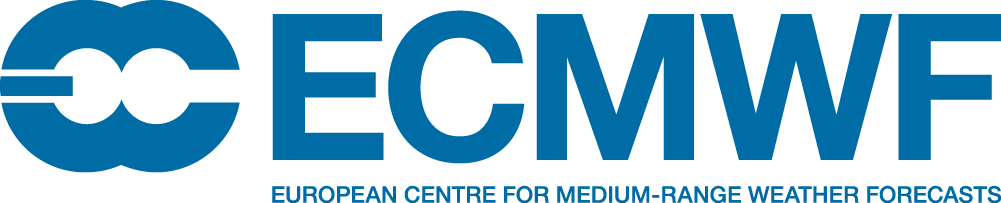
</div>

# 	AIFS ENS Ensemble mean and spread for 2m temperature

This notebook will provide you guidance how to explore and plot ECMWF open dataset to produce the map from the ECMWF open charts web product.  
The original product can be found on this link: https://charts.ecmwf.int/products/aifs_ens_medium-2t-mean-spread  


<div class="output_png output_subarea output_execute_result">
<center>
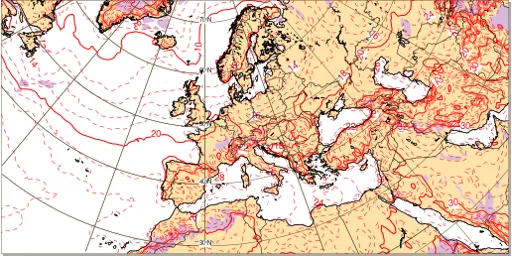</center>
</div>

The full list of available AIFS Open data products can be found [here](https://www.ecmwf.int/en/forecasts/dataset/aifs-machine-learning-data), and more information can be found in the [User documentation](https://confluence.ecmwf.int/display/DAC/ECMWF+open+data%3A+real-time+forecasts+from+IFS+and+AIFS).  

Access to ECMWF AIFS data is governed by the Creative Commons CC-BY-4.0 licence and associated [Terms of Use](https://apps.ecmwf.int/datasets/licences/general/).  

<sub> In applying this licence, ECMWF does not waive the privileges and immunities granted to it by virtue of its status as an intergovernmental organisation nor does it submit to any jurisdiction </sub>

To find out how to obtain the access to the full forecast dataset [Access page](https://www.ecmwf.int/en/forecasts/accessing-forecasts).

## Retrieve Data
This product takes in input 1 parameter:

* [2 metre temperature](https://codes.ecmwf.int/grib/param-db/167)

In this example, we will use: 
- [**ecmwf.opendata**](https://github.com/ecmwf/ecmwf-opendata) Client to download the data
- [**Metview**](https://metview.readthedocs.io/en/latest/) library to read, process and plot the data 

First we need to install them in the current Jupyter kernel:  
<div class="alert alert-block alert-info">
<b>Note:</b> If you are running the notebook on MyBinder or already have the libraries installed, go directly to importing the libraries.
</div>
<div class="alert alert-block alert-info">
<b>Note:</b> If you don't have these libraries installed, click on three dots below, uncomment the code and run the next two cells.
</div>

In [1]:
#!pip install ecmwf-opendata

In [1]:
#!conda install metview metview-python

In [1]:
import metview as mv
from ecmwf.opendata import Client

In [ ]:
client = Client("ecmwf", beta=False, model="aifs-ens")

For the AIFS ENS 2m temperature, ensemble mean and spread are available for download.  

Ensemble mean and ensemble spread have different **type** in the request.
One data request can have only one type, so we need to have two requests to download these datasets.

In [3]:
parameters = ['2t']
em_filename = 'aifs_ens_medium-2t-mean-spread-em.grib'
es_filename = 'aifs_ens_medium-2t-mean-spread-es.grib'
em_filename,es_filename

('aifs_ens_medium-2t-mean-spread-em.grib',
 'aifs_ens_medium-2t-mean-spread-es.grib')

Setting date to 0 will download today's data. 
Removing date and time altogether from the request will download the latest data.  
Try commenting out date and time to download latest forecast!

In [4]:
client.retrieve(
    date=0,
    time=0,
    step=120,
    stream="enfo",
    type="em",
    levtype="sfc",
    param=parameters,
    target = em_filename
)

20260730000000-240h-enfo-ep.grib2:   0%|          | 0.00/494k [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


In [5]:
client.retrieve(
    date=0,
    time=0,
    step=120,
    stream="enfo",
    type="es",
    levtype="sfc",
    param=parameters,
    target = es_filename
)

20260730000000-240h-enfo-ep.grib2:   0%|          | 0.00/641k [00:00<?, ?B/s]

## Reading and processing the data
Now we can use **Metview's read() function** to read the files.

In [6]:
t2_em = mv.read(em_filename)
t2_es = mv.read(es_filename)
t2_es = t2_es*1.0

The **describe()** function will give us the overview of the dataset.  

In [7]:
t2_em.describe()

parameter,typeOfLevel,level,date,time,step,number,paramId,class,stream,type,experimentVersionNumber
2t,heightAboveGround,2,20260730,0,120,None,167,ai,enfo,em,0001


And specifying the parameter shortName in the describe function, we can get more detailed information about the data.

In [8]:
t2_es.describe('2t')

shortName,2t
name,2 metre temperature
paramId,167
units,K
typeOfLevel,heightAboveGround
level,2
date,20260730
time,0
step,120
number,None
class,ai


We can use **ls()** function to list all the fields in the file we downloaded.

In [9]:
t2_es.ls()

,centre,shortName,typeOfLevel,level,dataDate,dataTime,stepRange,dataType,number,gridType
Message,,,,,,,,,,
0,ecmf,2t,heightAboveGround,2,20260730,0,120,es,None,regular_ll


## Plotting the data
And finally, we can plot the data on the map. 

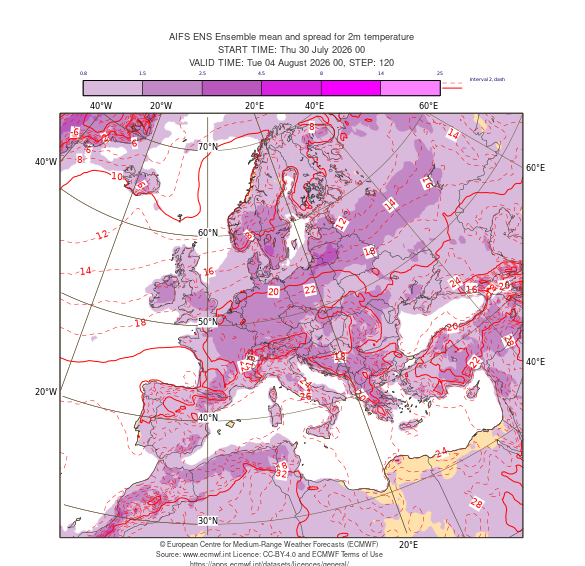

In [10]:
# define coastlines
coast = mv.mcoast(
    map_coastline_colour="charcoal",
    map_coastline_resolution="medium",
    map_coastline_land_shade="on",
    map_coastline_land_shade_colour="cream",
    map_coastline_sea_shade="off",
    map_boundaries="on",
    map_boundaries_colour= "charcoal",
    map_boundaries_thickness = 1,
    map_disputed_boundaries = "off",
    map_grid_colour="tan",
    map_label_height=0.35,
)

# define view
view = mv.geoview(
    area_mode="name",
    area_name="europe",
    coastlines=coast
)

#define styles
mean_contour = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "ct_red_i2_dash")

spread_shade = mv.mcont(legend= "on",
                contour_automatics_settings = "style_name",
                contour_style_name = "sh_blu_f008t25")

title = mv.mtext(
    text_lines=["AIFS ENS Ensemble mean and spread for 2m temperature", 
           "START TIME: <grib_info key='base-date' format='%a %d %B %Y %H' where='type=es'/> ",
           "VALID TIME: <grib_info key='valid-date' format='%a %d %B %Y %H' where='type=es'/>, STEP: <grib_info key='step' where='type=es'/>"],
    text_font_size=0.4,
    text_colour         = 'charcoal')

ecmwf_text = mv.mtext(    
    text_lines          = ["© European Centre for Medium-Range Weather Forecasts (ECMWF)",
                           "Source: www.ecmwf.int Licence: CC-BY-4.0 and ECMWF Terms of Use",
                            "https://apps.ecmwf.int/datasets/licences/general/"],
    text_justification  = 'center',
    text_font_size      = 0.3,
    text_mode           = "positional",
    text_box_x_position = 6.,
    text_box_y_position = -0.2,
    text_box_x_length   = 8,
    text_box_y_length   = 2,
    text_colour         = 'charcoal')

# generate plot
mv.setoutput('jupyter', plot_widget=False)
mv.plot(view, t2_es, spread_shade, t2_em, mean_contour, title, ecmwf_text)

To generate the png file you can run the following cell.

In [18]:
png = mv.png_output(
      output_name = "aifs_ens_medium-2t-mean-spread",   # specify relative or full path
      output_title = "aifs_ens_medium-2t-mean-spread",    # title used by a viewer
      output_width = 1000,                 # set width in pixels
)
mv.setoutput(png)
mv.plot(view, t2_es, spread_shade, t2_em, mean_contour, title, ecmwf_text)

Note that plot produced using open data dataset will slightly differ from one from Open Charts. This is due to different resolution of the data.  
Open data is on 0.25x0.25 resolution, while high resolution data is 0.1x0.1 grid.